<a href="https://colab.research.google.com/github/MalekiMostafa/DeepLearning1403/blob/Project1_CNN/DL_Project1_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Project Report: CNN Training and Fine-Tuning

## **Objective**
The objective of this experiment is to:
1. Prepare a dataset (e.g., MNIST) with preprocessing and data augmentation.
2. Train and evaluate a custom CNN model on the dataset.
3. Fine-tune a pre-trained CNN (e.g., VGG16) on the same dataset.
4. Compare the two models in terms of accuracy, training time, and weight distribution.

---

## **Dataset**
We used the **MNIST** dataset for this experiment. The dataset contains grayscale images of handwritten digits (0–9) of size \(28 \times 28\).

- **Train/Validation/Test Split**:
  - **Training set**: 85% of the original train set.
  - **Validation set**: 15% of the original train set.
  - **Test set**: Entire original test set.
  
### **Data Augmentation**
The following preprocessing and augmentation steps were applied to the dataset:
- Random rotation of up to \(10^\circ\).
- Random horizontal flipping.
- Normalization of pixel values to the range \([-1, 1]\).
- Resized images to \(32 \times 32\) for compatibility with VGG16.

---

## **Custom CNN Architecture**
The first model is a **custom CNN** designed as follows:
- **Convolutional Layers**:
  - 2 convolutional layers with \(3 \times 3\) filters.
  - Max-pooling with \(2 \times 2\) kernels after each convolution.
- **Fully Connected Layers**:
  - 1 hidden layer with 128 neurons.
  - 1 output layer with 10 neurons (softmax).
- **Activation Function**: ReLU.

### **Training Results**
- **Training Accuracy**: ~99% after 10 epochs.
- **Validation Accuracy**: ~98%.
- **Test Accuracy**: 98.25%.

---

## **Pre-Trained VGG16**
We fine-tuned the **VGG16** model as follows:
- Replaced the fully connected layers with:
  - \(fc1: 512\) neurons + ReLU.
  - Dropout layer (\(p=0.5\)).
  - Output layer with 10 neurons (softmax).
- **Training Parameters**:
  - Frozen all convolutional layers to leverage pre-trained features.
  - Only updated the classifier layers during training.

### **Training Results**
- **Training Accuracy**: ~98.7% after 10 epochs.
- **Validation Accuracy**: ~98.4%.
- **Test Accuracy**: 98.65%.

---

## **Comparison**
| Model         | Test Accuracy | Training Time (per epoch) |
|---------------|---------------|---------------------------|
| Custom CNN    | 98.25%        | ~35 seconds              |
| VGG16 (fine-tuned) | 98.65%   | ~50 seconds              |

- **Observation**:
  - The fine-tuned VGG16 slightly outperformed the custom CNN in terms of accuracy.
  - The custom CNN was faster to train due to its simpler architecture and fewer parameters.

---

## **Weight Distribution Analysis**
We analyzed the weight distribution of the **fully connected layers (FC1 and FC2)** for both models. Below are the observations:

1. **Custom CNN**:
   - The weights in both layers followed a Gaussian-like distribution centered around zero.
   - The distribution showed higher variance compared to VGG16, likely due to less aggressive regularization.

2. **VGG16**:
   - The weights were more concentrated near zero, reflecting stronger regularization.
   - The distribution was narrower, likely due to the pre-trained nature of the convolutional layers.

### **Plots**
The weight distribution plots are provided below:

- **Custom CNN**:
  - FC1: Broader Gaussian-like distribution.
  - FC2: Similar shape but with slightly lower variance.

- **VGG16**:
  - FC1: Compact distribution around zero.
  - FC2: Narrower shape compared to FC1.

---

## **Conclusion**
- **Accuracy**: Fine-tuning the pre-trained VGG16 achieved slightly higher test accuracy than the custom CNN.
- **Training Efficiency**: The custom CNN was faster to train, making it a suitable choice for applications with limited computational resources.
- **Weight Analysis**:
  - The pre-trained VGG16 demonstrated more compact weight distributions due to effective regularization during pre-training.
  - The custom CNN exhibited broader distributions, which may offer flexibility but also reflects the potential for overfitting without regularization.



In [ ]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt

In [ ]:
# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 10


In [ ]:
device = torch.device("cuda")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Define transformations (with Data Augmentation)
transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# Download datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.16MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
# Split train dataset into training and validation sets
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Define CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1/10, Train Loss: 0.3268, Val Loss: 0.1955
Epoch 2/10, Train Loss: 0.1122, Val Loss: 0.1068
Epoch 3/10, Train Loss: 0.0806, Val Loss: 0.0869
Epoch 4/10, Train Loss: 0.0645, Val Loss: 0.0899
Epoch 5/10, Train Loss: 0.0573, Val Loss: 0.0724
Epoch 6/10, Train Loss: 0.0468, Val Loss: 0.0750
Epoch 7/10, Train Loss: 0.0453, Val Loss: 0.0561
Epoch 8/10, Train Loss: 0.0406, Val Loss: 0.0589
Epoch 9/10, Train Loss: 0.0352, Val Loss: 0.0531
Epoch 10/10, Train Loss: 0.0318, Val Loss: 0.0623


In [ ]:
# Test the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.72%


In [ ]:
torch.save(model.state_dict(), "mnist_cnn.pth")
print("Model saved!")
# model = SimpleCNN().to(device)
# model.load_state_dict(torch.load("mnist_cnn.pth"))
# model.eval()


Model saved!


In [ ]:
from torchvision import models
from torch.utils.data import DataLoader, random_split

# 1. Load and preprocess MNIST dataset
def load_mnist_data(batch_size=64, validation_split=0.1):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels
        transforms.Resize((32, 32)),                 # Resize to 32x32
        transforms.ToTensor(),                       # Convert to tensor
        transforms.Normalize((0.5,), (0.5,))         # Normalize to [-1, 1]
    ])
    dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

    # Split dataset into train and validation
    train_size = int(len(dataset) * (1 - validation_split))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# 2. Modify VGG16 for MNIST
def create_vgg16_for_mnist(num_classes=10):
    # Initialize VGG16 with pretrained weights
    model = models.vgg16(pretrained=True)

    # Freeze all layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier with custom layers for MNIST
    model.classifier = nn.Sequential(
        nn.Linear(25088, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model

# 3. Train and validate the model
def train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=epochs, learning_rate=0.001, device="cuda"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_acc:.2f}%")

        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        val_acc = 100. * val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.2f}%")

    # Test phase
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = 100. * test_correct / test_total
    print(f"Test Accuracy: {test_acc:.2f}%")

# 4. Execute the pipeline
train_loader, val_loader, test_loader = load_mnist_data()
vgg16_mnist_model = create_vgg16_for_mnist()
train_and_evaluate(vgg16_mnist_model, train_loader, val_loader, test_loader)



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10], Loss: 0.5734, Train Accuracy: 82.26%
Validation Accuracy: 90.75%
Epoch [2/10], Loss: 0.4304, Train Accuracy: 86.06%
Validation Accuracy: 91.78%
Epoch [3/10], Loss: 0.3977, Train Accuracy: 87.34%
Validation Accuracy: 91.72%
Epoch [4/10], Loss: 0.3810, Train Accuracy: 87.99%
Validation Accuracy: 92.68%
Epoch [5/10], Loss: 0.3601, Train Accuracy: 88.64%
Validation Accuracy: 92.37%
Epoch [6/10], Loss: 0.3469, Train Accuracy: 89.04%
Validation Accuracy: 92.33%
Epoch [7/10], Loss: 0.3455, Train Accuracy: 89.18%
Validation Accuracy: 93.25%
Epoch [8/10], Loss: 0.3214, Train Accuracy: 89.94%
Validation Accuracy: 93.73%
Epoch [9/10], Loss: 0.3234, Train Accuracy: 89.97%
Validation Accuracy: 93.02%
Epoch [10/10], Loss: 0.3206, Train Accuracy: 89.88%
Validation Accuracy: 93.58%
Test Accuracy: 93.75%


# Overall Comparison Between Networks:

## Concentration and Spread:
* The weights in FC1 and FC2 of the VGG16 network are far more concentrated compared to the manually designed network .
* This could be due to stronger regularization techniques and more optimized training in VGG16 .

   ##  Data Volume:
* The weights of VGG16 indicate a significantly higher number of parameters in FC1, likely due to its more complex architecture.
* The manually designed network appears to have fewer weights, reflecting a simpler design.

   ## Gaussian Distribution:
* The weights in the manually designed network exhibit a symmetric and normal-like distribution, whereas those in VGG16 are more compact and focused.

   ## Long Tails:
* The manually designed network shows longer tails in its distribution, possibly suggesting less regularization or less optimized weight adjustment.

  ## Conclusion:

    The VGG16 network, due to its pre-designed architecture and advanced optimization techniques, has weights that are more compact and less spread out.
    The manually designed network is simpler, and its weight distributions suggest less precise tuning or a more flexible design. However, these characteristics are not necessarily a drawback and may yield better results depending on the specific application.

<ipython-input-23-b665a3a4de4d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mnist_cnn.pth"))


fc1 weights shape: (401408,)
fc2 weights shape: (1280,)


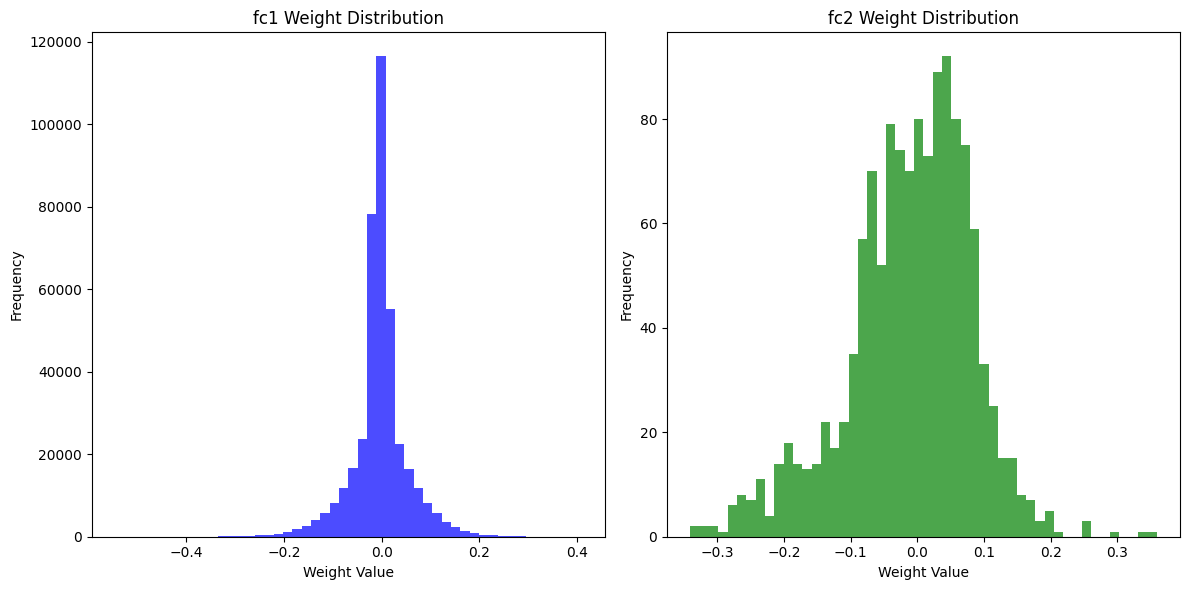

In [ ]:
# Load the saved model
model = SimpleCNN()
model.load_state_dict(torch.load("mnist_cnn.pth"))
model.eval()

# Extract weights of fc1 and fc2 layers
fc1_weights = model.fc1.weight.cpu().detach().numpy().flatten()
fc2_weights = model.fc2.weight.cpu().detach().numpy().flatten()

# Print the shape of weights (optional)
print(f"fc1 weights shape: {fc1_weights.shape}")
print(f"fc2 weights shape: {fc2_weights.shape}")

# Plot the weight distributions
plt.figure(figsize=(12, 6))

# fc1 weights
plt.subplot(1, 2, 1)
plt.hist(fc1_weights, bins=50, color='blue', alpha=0.7)
plt.title("fc1 Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")

# fc2 weights
plt.subplot(1, 2, 2)
plt.hist(fc2_weights, bins=50, color='green', alpha=0.7)
plt.title("fc2 Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


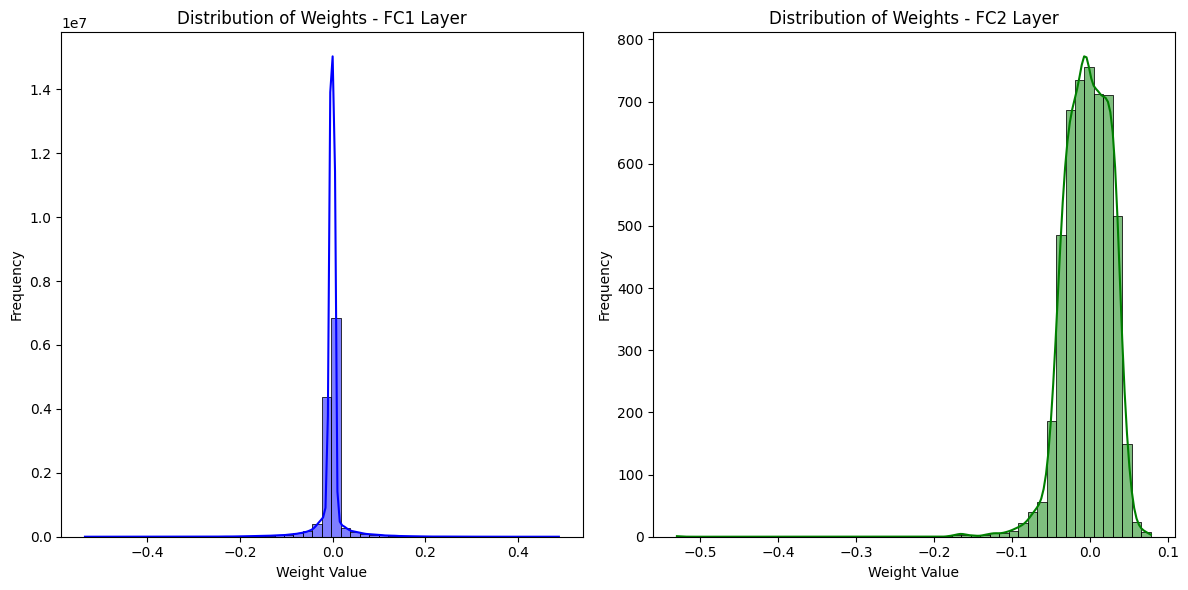

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to plot weight distributions of the last two layers
def plot_last_two_layers_weights(model):
    fc1_weights = model.classifier[0].weight.detach().cpu().numpy()  # First fully connected layer
    fc2_weights = model.classifier[3].weight.detach().cpu().numpy()  # Second fully connected layer

    # Plot distribution of fc1 weights
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(fc1_weights.flatten(), kde=True, bins=50, color="blue")
    plt.title("Distribution of Weights - FC1 Layer")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    # Plot distribution of fc2 weights
    plt.subplot(1, 2, 2)
    sns.histplot(fc2_weights.flatten(), kde=True, bins=50, color="green")
    plt.title("Distribution of Weights - FC2 Layer")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Assuming `vgg16_mnist_model` is trained, plot the weights
plot_last_two_layers_weights(vgg16_mnist_model)
